# CNN Modernas — Transfer Learning
| IA 5.2 Computer Vision  
| FCEIA - UNR

En esta práctica usamos modelos CNN ya entrenados y los adaptamos a un nuevo dataset.
El flujo es siempre el mismo:

1. **Cargar** un modelo pre-entrenado en ImageNet
2. **Congelar** el backbone (preservamos lo que ya aprendió)
3. **Reemplazar** la última capa por una nueva adaptada a nuestras clases
4. **Entrenar** solo esa capa nueva

Al final comparamos tres modelos distintos: accuracy, velocidad y tamaño.

---
## Instalación

In [1]:
# !pip install torch torchvision

## Librerías

In [2]:
import ssl
import time
import torch
import torch.nn as nn
import torchvision
import torchvision.models as models
import torchvision.transforms as T
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

ssl._create_default_https_context = ssl._create_unverified_context

print(f"PyTorch: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

PyTorch: 2.10.0+cu128
Dispositivo: cuda


---
# 1. Dataset — STL-10

**STL-10** tiene 10 clases de objetos (avión, pájaro, auto, etc.) con imágenes de 96×96 px.
- `train`: 5 000 imágenes — `test`: 8 000 imágenes

> **¿Por qué hay más imágenes de test que de train?** Es intencional.
> STL-10 fue diseñado para investigar aprendizaje con **pocos datos etiquetados**.
> Al tener solo 5 000 imágenes de train (500 por clase), fuerza a usar técnicas como
> transfer learning para lograr buen accuracy. El test set es más grande (8 000)
> para tener una evaluación estadísticamente más confiable.

Como los modelos pre-entrenados esperan 224×224, lo primero que hace el transform es redimensionar.
También aplicamos la **normalización estándar de ImageNet** (los modelos la necesitan porque fueron entrenados con esos valores).

In [3]:
BATCH_SIZE = 32
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

tfm_train = T.Compose([
    T.Resize(224),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

tfm_val = T.Compose([
    T.Resize(224),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

train_ds = datasets.STL10("./data", split="train", download=True, transform=tfm_train)
val_ds   = datasets.STL10("./data", split="test",  download=True, transform=tfm_val)

# Subconjunto para entrenar más rápido en clase (descomentar si hace falta):
# from torch.utils.data import Subset
# train_ds = Subset(train_ds, range(800))
# val_ds   = Subset(val_ds,   range(400))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

CLASES     = train_ds.classes
NUM_CLASES = len(CLASES)
print(f"Clases: {CLASES}")
print(f"Train: {len(train_ds)} imgs  |  Val: {len(val_ds)} imgs")

Clases: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Train: 5000 imgs  |  Val: 8000 imgs


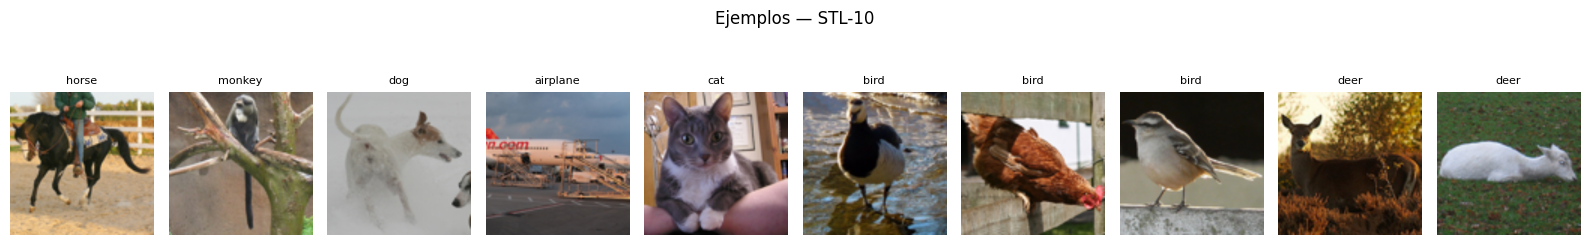

In [4]:
# Mostrar ejemplos del dataset
imgs, labels = next(iter(val_loader))
mean_t = torch.tensor(MEAN).view(3,1,1)
std_t  = torch.tensor(STD).view(3,1,1)

fig, axes = plt.subplots(1, 10, figsize=(16, 2.5))
for i, ax in enumerate(axes):
    img = (imgs[i] * std_t + mean_t).clamp(0, 1).permute(1, 2, 0)
    ax.imshow(img); ax.set_title(CLASES[labels[i]], fontsize=8); ax.axis("off")
plt.suptitle("Ejemplos — STL-10", y=1.05)
plt.tight_layout()
plt.show()

## ¿Qué hace el data augmentation?

`RandomHorizontalFlip` es solo una de muchas transformaciones posibles.
Veamos cómo se ve la **misma imagen** cuando le aplicamos distintas augmentaciones.

Esto le permite al modelo ver más variaciones durante el entrenamiento, lo que mejora la generalización.

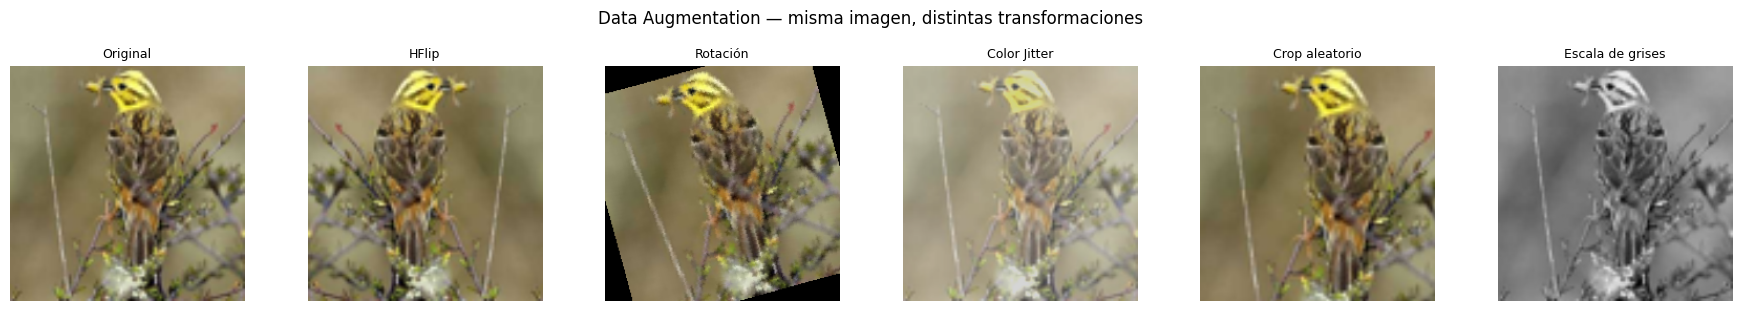

In [5]:
# Visualizar data augmentation: la misma imagen con distintas transformaciones
augmentaciones = {
    "Original":         T.Compose([T.Resize(224), T.ToTensor()]),
    "HFlip":            T.Compose([T.Resize(224), T.RandomHorizontalFlip(p=1.0), T.ToTensor()]),
    "Rotación":         T.Compose([T.Resize(224), T.RandomRotation(30), T.ToTensor()]),
    "Color Jitter":     T.Compose([T.Resize(224), T.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5), T.ToTensor()]),
    "Crop aleatorio":   T.Compose([T.Resize(256), T.RandomCrop(224), T.ToTensor()]),
    "Escala de grises": T.Compose([T.Resize(224), T.RandomGrayscale(p=1.0), T.ToTensor()]),
}

# Tomamos una imagen del dataset sin transformar
from PIL import Image
sample_img = train_ds.dataset.data[0] if hasattr(train_ds, 'dataset') else train_ds.data[0]
sample_img = Image.fromarray(sample_img.transpose(1, 2, 0))  # STL-10 guarda en CHW

fig, axes = plt.subplots(1, len(augmentaciones), figsize=(18, 3))
for ax, (nombre, tfm) in zip(axes, augmentaciones.items()):
    img_t = tfm(sample_img).permute(1, 2, 0).clamp(0, 1)
    ax.imshow(img_t); ax.set_title(nombre, fontsize=9); ax.axis("off")
plt.suptitle("Data Augmentation — misma imagen, distintas transformaciones", y=1.02)
plt.tight_layout(); plt.show()

---
# 2. ¿Qué modelos tenemos disponibles?

`torchvision.models` incluye decenas de arquitecturas pre-entrenadas.
Cada una representa un trade-off distinto entre accuracy y tamaño:

- **ResNet**: clásico y sólido, buen punto de partida
- **EfficientNet**: más eficiente — mismo accuracy con menos parámetros
- **MobileNet**: ultra liviano, pensado para correr en celulares y dispositivos edge
- **ConvNeXt**: diseño moderno inspirado en Vision Transformers


In [6]:
# Cuántos parámetros tiene cada modelo
zoo = [
    ("ResNet-50",          models.resnet50),
    ("EfficientNet-B0",    models.efficientnet_b0),
    ("MobileNet-V3 Small", models.mobilenet_v3_small),
    ("ConvNeXt-Tiny",      models.convnext_tiny),
]

print(f"{'Modelo':<22}  {'Parámetros':>12}")
print("-" * 36)
for nombre, fn in zoo:
    m = fn(weights=None)
    params = sum(p.numel() for p in m.parameters()) / 1e6
    print(f"{nombre:<22}  {params:>10.1f} M")

Modelo                    Parámetros
------------------------------------
ResNet-50                     25.6 M
EfficientNet-B0                5.3 M
MobileNet-V3 Small             2.5 M
ConvNeXt-Tiny                 28.6 M


## ¿Qué aprendió el backbone?

Un modelo pre-entrenado en ImageNet ya "sabe" detectar **bordes, texturas, formas y objetos**.
Podemos visualizarlo pasando una imagen por las capas internas de un ResNet y viendo los **feature maps** que produce.

- Las **primeras capas** detectan bordes y texturas simples
- Las **capas intermedias** detectan patrones más complejos (ojos, ruedas, etc.)
- Las **capas finales** codifican conceptos abstractos de alto nivel

Esto es lo que hace tan valioso al transfer learning: esas features son útiles para casi cualquier tarea visual.

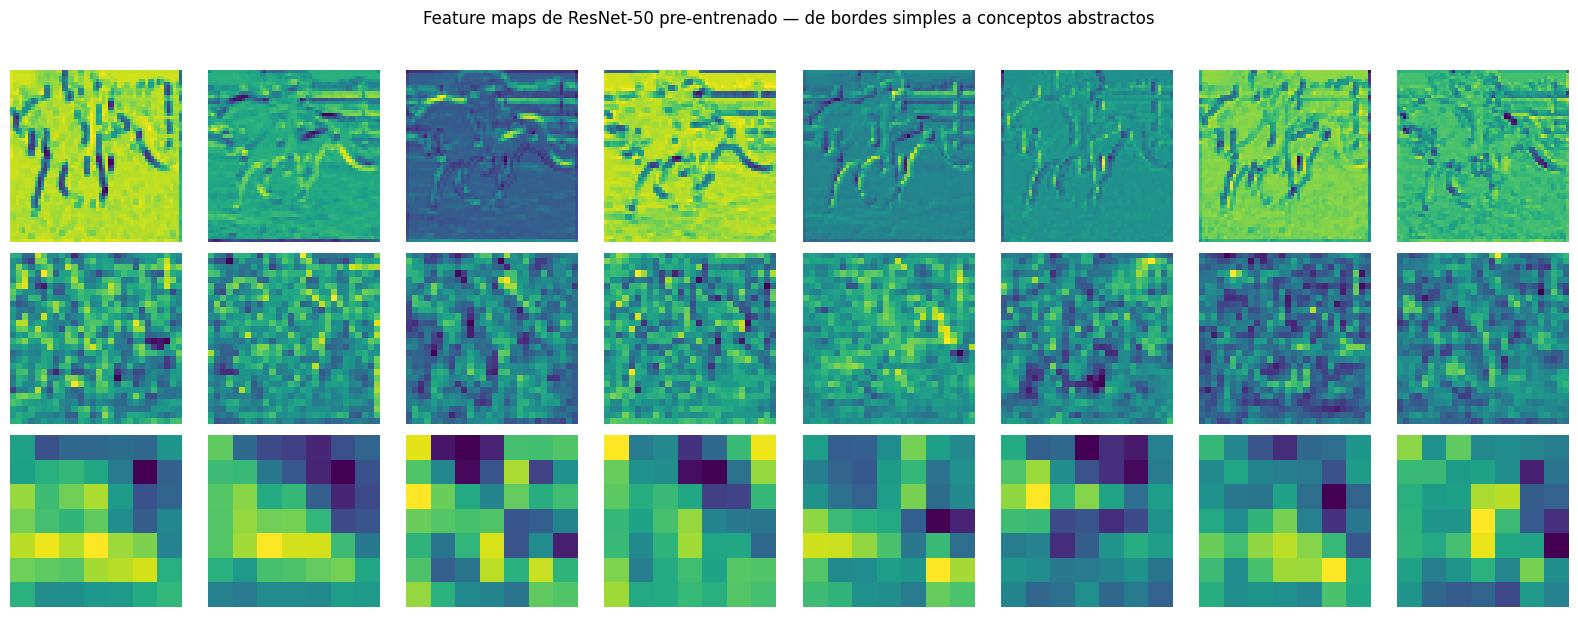

In [7]:
# Visualizar feature maps de un ResNet-50 pre-entrenado
resnet_vis = models.resnet50(weights=models.ResNet50_Weights.DEFAULT).to(device).eval()

# Capturar activaciones de capas clave con hooks
activaciones = {}
def hook_fn(nombre):
    def hook(module, input, output):
        activaciones[nombre] = output.detach().cpu()
    return hook

capas_interes = {
    "Conv inicial (bordes)": resnet_vis.layer1[0].conv1,
    "Capa media (patrones)": resnet_vis.layer2[-1].conv3,
    "Capa profunda (conceptos)": resnet_vis.layer4[-1].conv3,
}
handles = [capa.register_forward_hook(hook_fn(nombre)) for nombre, capa in capas_interes.items()]

# Pasar una imagen por el modelo
img_ejemplo = imgs[:1].to(device)  # del batch que ya cargamos
with torch.no_grad():
    resnet_vis(img_ejemplo)

# Limpiar hooks
for h in handles: h.remove()
del resnet_vis

# Visualizar 8 feature maps de cada capa
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for fila, (nombre, feat) in enumerate(activaciones.items()):
    for col in range(8):
        axes[fila, col].imshow(feat[0, col], cmap="viridis")
        axes[fila, col].axis("off")
    axes[fila, 0].set_ylabel(nombre, fontsize=8, rotation=0, labelpad=110, va="center")

plt.suptitle("Feature maps de ResNet-50 pre-entrenado — de bordes simples a conceptos abstractos", y=1.02)
plt.tight_layout(); plt.show()

---
# 3. Adaptar un modelo a nuestro dataset

La función `preparar_modelo` hace tres cosas:

1. Descarga el modelo con los pesos pre-entrenados de ImageNet
2. Congela todos los parámetros (así no los modificamos al entrenar)
3. Reemplaza la última capa por una nueva con la cantidad de clases de STL-10

La nueva capa **no está congelada**, así que es la única que se va a entrenar.

### ¿Con qué datos se entrenó cada modelo?

Todos los modelos usan pesos entrenados en **ImageNet-1K** (ILSVRC 2012): 1.28 millones de imágenes, 1 000 clases.

| Modelo | Pesos (`DEFAULT`) | Top-1 Acc en ImageNet | Notas |
|---|---|---|---|
| ResNet-50 | `IMAGENET1K_V2` | 80.9% | Receta de entrenamiento mejorada (2021) |
| EfficientNet-B0 | `IMAGENET1K_V1` | 77.7% | Receta original del paper |
| MobileNet-V3 Small | `IMAGENET1K_V1` | 67.7% | Optimizado para velocidad, no accuracy |

> **¿Las imágenes de STL-10 están en ImageNet?** No. STL-10 usa imágenes de una fuente distinta.
> Las 10 clases de STL-10 (airplane, bird, car, etc.) existen como categorías en ImageNet,
> pero las **imágenes son diferentes**. Por eso es transfer learning legítimo:
> el modelo aprendió features generales de ImageNet y las aplica a imágenes nuevas que nunca vio.

In [8]:
def preparar_modelo(nombre, num_clases):
    """
    Carga un modelo pre-entrenado y lo adapta al número de clases.
    Solo la última capa queda entrenable.
    """
    if nombre == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        for p in m.parameters(): p.requires_grad = False
        m.fc = nn.Linear(m.fc.in_features, num_clases)

    elif nombre == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        for p in m.parameters(): p.requires_grad = False
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_clases)

    elif nombre == "mobilenet_v3_small":
        m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        for p in m.parameters(): p.requires_grad = False
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, num_clases)

    total    = sum(p.numel() for p in m.parameters()) / 1e6
    entrena  = sum(p.numel() for p in m.parameters() if p.requires_grad) / 1e6
    print(f"{nombre}: {total:.1f}M params totales | {entrena:.3f}M entrenables")
    return m.to(device)

---
# 4. Función de entrenamiento

El loop de entrenamiento siempre sigue la misma lógica:
1. Pasar las imágenes por el modelo → obtener predicciones
2. Calcular cuánto se equivocó (loss)
3. Propagar el error hacia atrás (backprop)
4. Actualizar los pesos de la capa nueva

Al final de cada época evaluamos en el set de validación para ver cómo generaliza.

In [9]:
def entrenar(modelo, train_loader, val_loader, epochs=5, lr=1e-3):
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, modelo.parameters()), lr=lr
    )
    criterio = nn.CrossEntropyLoss()
    historia = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

    for ep in range(1, epochs + 1):
        # -- Entrenamiento --
        modelo.train()
        ok, total, loss_sum = 0, 0, 0.0
        for imgs, y in train_loader:
            imgs, y = imgs.to(device), y.to(device)
            optimizer.zero_grad()
            out  = modelo(imgs)
            loss = criterio(out, y)
            loss.backward()
            optimizer.step()
            ok       += (out.argmax(1) == y).sum().item()
            total    += y.size(0)
            loss_sum += loss.item() * y.size(0)

        # -- Validación --
        modelo.eval()
        ok_v, total_v, loss_v_sum = 0, 0, 0.0
        with torch.no_grad():
            for imgs, y in val_loader:
                imgs, y = imgs.to(device), y.to(device)
                out_v    = modelo(imgs)
                ok_v     += (out_v.argmax(1) == y).sum().item()
                total_v  += y.size(0)
                loss_v_sum += criterio(out_v, y).item() * y.size(0)

        historia["train_acc"].append(ok / total)
        historia["val_acc"].append(ok_v / total_v)
        historia["train_loss"].append(loss_sum / total)
        historia["val_loss"].append(loss_v_sum / total_v)
        print(f"  Época {ep}/{epochs} — train: {ok/total:.3f}  val: {ok_v/total_v:.3f}  loss: {loss_sum/total:.4f}")

    return historia

---
# 5. Experimentos

Entrenamos los tres modelos con las mismas condiciones:
mismo dataset, mismo número de épocas, mismo learning rate.
Así la comparación es justa.

In [10]:
print("ResNet-50")
resnet = preparar_modelo("resnet50", NUM_CLASES)
hist_resnet = entrenar(resnet, train_loader, val_loader, epochs=5)

ResNet-50
resnet50: 23.5M params totales | 0.020M entrenables
  Época 1/5 — train: 0.871  val: 0.958  loss: 0.7031
  Época 2/5 — train: 0.965  val: 0.967  loss: 0.1976
  Época 3/5 — train: 0.968  val: 0.970  loss: 0.1402
  Época 4/5 — train: 0.977  val: 0.969  loss: 0.1012
  Época 5/5 — train: 0.981  val: 0.973  loss: 0.0850


In [11]:
print("EfficientNet-B0")
efficientnet = preparar_modelo("efficientnet_b0", NUM_CLASES)
hist_efficientnet = entrenar(efficientnet, train_loader, val_loader, epochs=5)

EfficientNet-B0
efficientnet_b0: 4.0M params totales | 0.013M entrenables
  Época 1/5 — train: 0.822  val: 0.937  loss: 0.8735
  Época 2/5 — train: 0.908  val: 0.940  loss: 0.3660
  Época 3/5 — train: 0.926  val: 0.939  loss: 0.2804
  Época 4/5 — train: 0.929  val: 0.939  loss: 0.2451
  Época 5/5 — train: 0.932  val: 0.948  loss: 0.2217


In [12]:
print("MobileNet-V3 Small")
mobilenet = preparar_modelo("mobilenet_v3_small", NUM_CLASES)
hist_mobilenet = entrenar(mobilenet, train_loader, val_loader, epochs=5)

MobileNet-V3 Small
mobilenet_v3_small: 1.5M params totales | 0.010M entrenables
  Época 1/5 — train: 0.832  val: 0.884  loss: 0.6856
  Época 2/5 — train: 0.911  val: 0.894  loss: 0.3066
  Época 3/5 — train: 0.926  val: 0.915  loss: 0.2463
  Época 4/5 — train: 0.928  val: 0.924  loss: 0.2210
  Época 5/5 — train: 0.939  val: 0.925  loss: 0.1953


---
# 6. Comparación de Modelos

In [13]:
resultados = [
    {"nombre": "ResNet-50",          "modelo": resnet,       "hist": hist_resnet},
    {"nombre": "EfficientNet-B0",    "modelo": efficientnet, "hist": hist_efficientnet},
    {"nombre": "MobileNet-V3 Small", "modelo": mobilenet,    "hist": hist_mobilenet},
]

# Medir tiempo de inferencia (ms por imagen)
dummy = torch.randn(1, 3, 224, 224).to(device)
for r in resultados:
    r["params_M"] = sum(p.numel() for p in r["modelo"].parameters()) / 1e6
    r["val_acc"]  = r["hist"]["val_acc"][-1]
    r["modelo"].eval()
    with torch.no_grad():
        for _ in range(5): r["modelo"](dummy)   # warmup
        t0 = time.time()
        for _ in range(50): r["modelo"](dummy)
        r["ms"] = (time.time() - t0) / 50 * 1000

print(f"{'Modelo':<22}  {'Params':>8}  {'Val Acc':>9}  {'Inferencia':>12}")
print("-" * 56)
for r in resultados:
    print(f"{r['nombre']:<22}  {r['params_M']:>6.1f} M  {r['val_acc']:>8.3f}  {r['ms']:>10.1f} ms")

Modelo                    Params    Val Acc    Inferencia
--------------------------------------------------------
ResNet-50                 23.5 M     0.973         1.4 ms
EfficientNet-B0            4.0 M     0.948         1.4 ms
MobileNet-V3 Small         1.5 M     0.925         0.9 ms


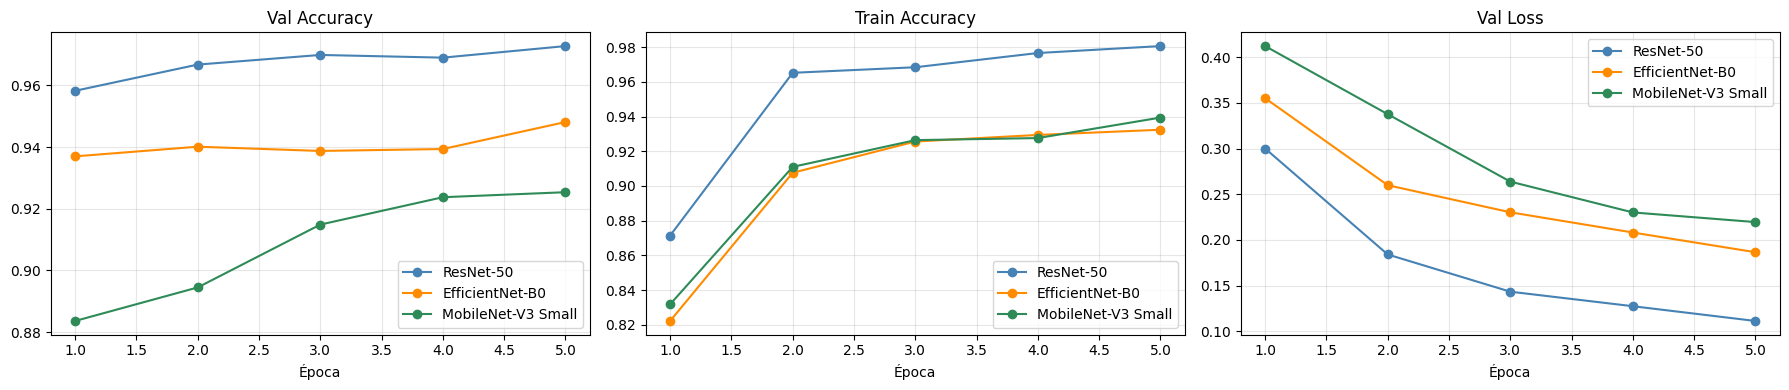

In [14]:
epocas  = range(1, 6)
colores = ["steelblue", "darkorange", "seagreen"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for r, c in zip(resultados, colores):
    axes[0].plot(epocas, r["hist"]["val_acc"],   marker="o", label=r["nombre"], color=c)
    axes[1].plot(epocas, r["hist"]["train_acc"],  marker="o", label=r["nombre"], color=c)
    axes[2].plot(epocas, r["hist"]["val_loss"],   marker="o", label=r["nombre"], color=c)

for ax, titulo in zip(axes, ["Val Accuracy", "Train Accuracy", "Val Loss"]):
    ax.set_title(titulo); ax.set_xlabel("Época")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

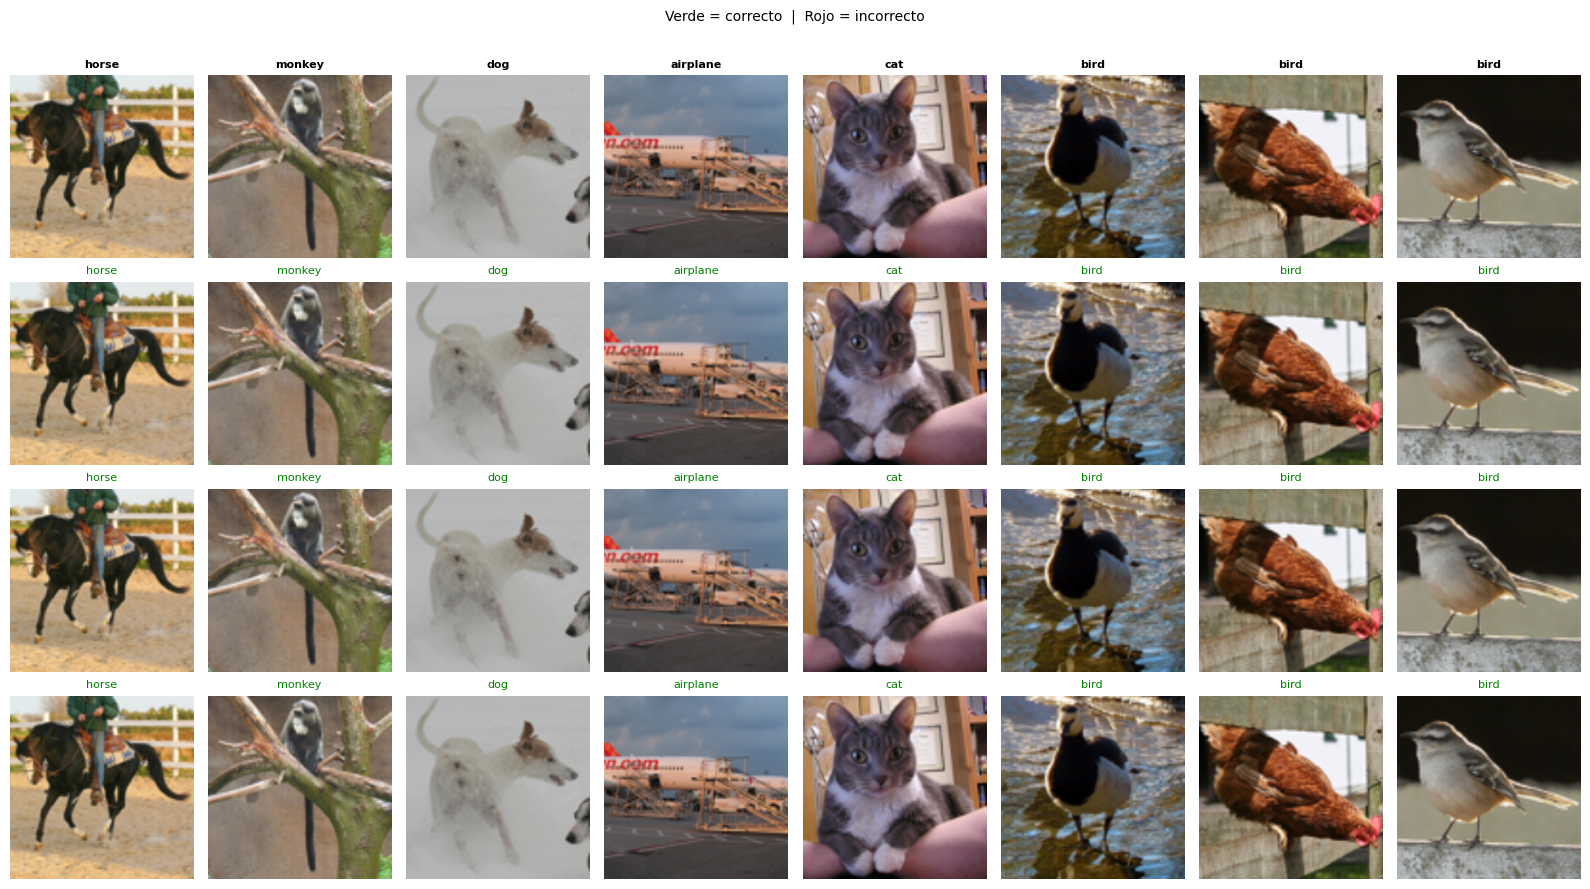

In [15]:
# Predicciones visuales: las mismas imágenes pasadas por los 3 modelos
imgs_batch, labels_real = next(iter(val_loader))
n = 8
imgs_show = imgs_batch[:n]
mean_t    = torch.tensor(MEAN).view(3,1,1)
std_t     = torch.tensor(STD).view(3,1,1)
imgs_disp = (imgs_show * std_t + mean_t).clamp(0, 1)

fig, axes = plt.subplots(len(resultados) + 1, n, figsize=(n * 2, (len(resultados) + 1) * 2.2))

# Fila 0 — etiquetas reales
for j in range(n):
    axes[0, j].imshow(imgs_disp[j].permute(1, 2, 0))
    axes[0, j].set_title(CLASES[labels_real[j]], fontsize=8, fontweight="bold")
    axes[0, j].axis("off")
axes[0, 0].set_ylabel("Real", fontsize=9, rotation=0, labelpad=36, va="center")

# Filas siguientes — predicciones de cada modelo
for i, r in enumerate(resultados):
    r["modelo"].eval()
    with torch.no_grad():
        preds = r["modelo"](imgs_show.to(device)).argmax(1).cpu()
    for j in range(n):
        color = "green" if preds[j] == labels_real[j] else "red"
        axes[i+1, j].imshow(imgs_disp[j].permute(1, 2, 0))
        axes[i+1, j].set_title(CLASES[preds[j]], fontsize=8, color=color)
        axes[i+1, j].axis("off")
    axes[i+1, 0].set_ylabel(r["nombre"], fontsize=8, rotation=0, labelpad=50, va="center")

plt.suptitle("Verde = correcto  |  Rojo = incorrecto", fontsize=10, y=1.01)
plt.tight_layout(); plt.show()

---
# 7. Análisis de errores

El accuracy global es un promedio que puede esconder problemas.
Veamos **cómo le va a cada modelo en cada clase** y dónde se equivocan más.

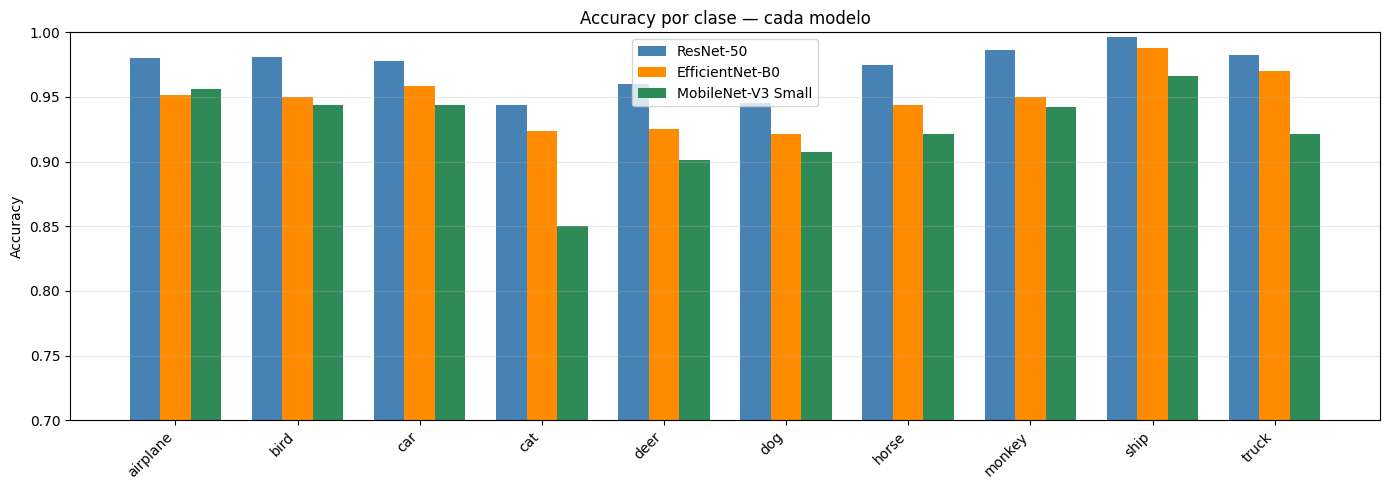


Clases más difíciles (menor accuracy promedio entre modelos):
  cat         0.906
  dog         0.925
  deer        0.929
  horse       0.947
  truck       0.958
  bird        0.958
  monkey      0.960
  car         0.960
  airplane    0.963
  ship        0.983


In [16]:
# Accuracy por clase para cada modelo
fig, ax = plt.subplots(figsize=(14, 5))
x = range(NUM_CLASES)
ancho = 0.25

for i, r in enumerate(resultados):
    r["modelo"].eval()
    ok_clase  = [0] * NUM_CLASES
    tot_clase = [0] * NUM_CLASES
    with torch.no_grad():
        for imgs_b, y_b in val_loader:
            preds = r["modelo"](imgs_b.to(device)).argmax(1).cpu()
            for pred, real in zip(preds, y_b):
                tot_clase[real] += 1
                if pred == real:
                    ok_clase[real] += 1
    acc_clase = [ok / tot if tot > 0 else 0 for ok, tot in zip(ok_clase, tot_clase)]
    r["acc_por_clase"] = acc_clase
    barras = [xi + i * ancho for xi in x]
    ax.bar(barras, acc_clase, ancho, label=r["nombre"], color=colores[i])

ax.set_xticks([xi + ancho for xi in x])
ax.set_xticklabels(CLASES, rotation=45, ha="right")
ax.set_ylabel("Accuracy"); ax.set_title("Accuracy por clase — cada modelo")
ax.legend(); ax.set_ylim(0.7, 1.0); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# Mostrar las clases más difíciles
print("\nClases más difíciles (menor accuracy promedio entre modelos):")
acc_promedio = {}
for c_idx, clase in enumerate(CLASES):
    acc_promedio[clase] = sum(r["acc_por_clase"][c_idx] for r in resultados) / len(resultados)
for clase, acc in sorted(acc_promedio.items(), key=lambda x: x[1]):
    print(f"  {clase:<10s}  {acc:.3f}")

## ¿Dónde se equivoca cada modelo?

Veamos ejemplos concretos de errores: 5 imágenes aleatorias por modelo donde la predicción fue **incorrecta**.
Esto ayuda a entender si los errores son "razonables" (confundir gato con perro) o "absurdos" (confundir avión con mono).

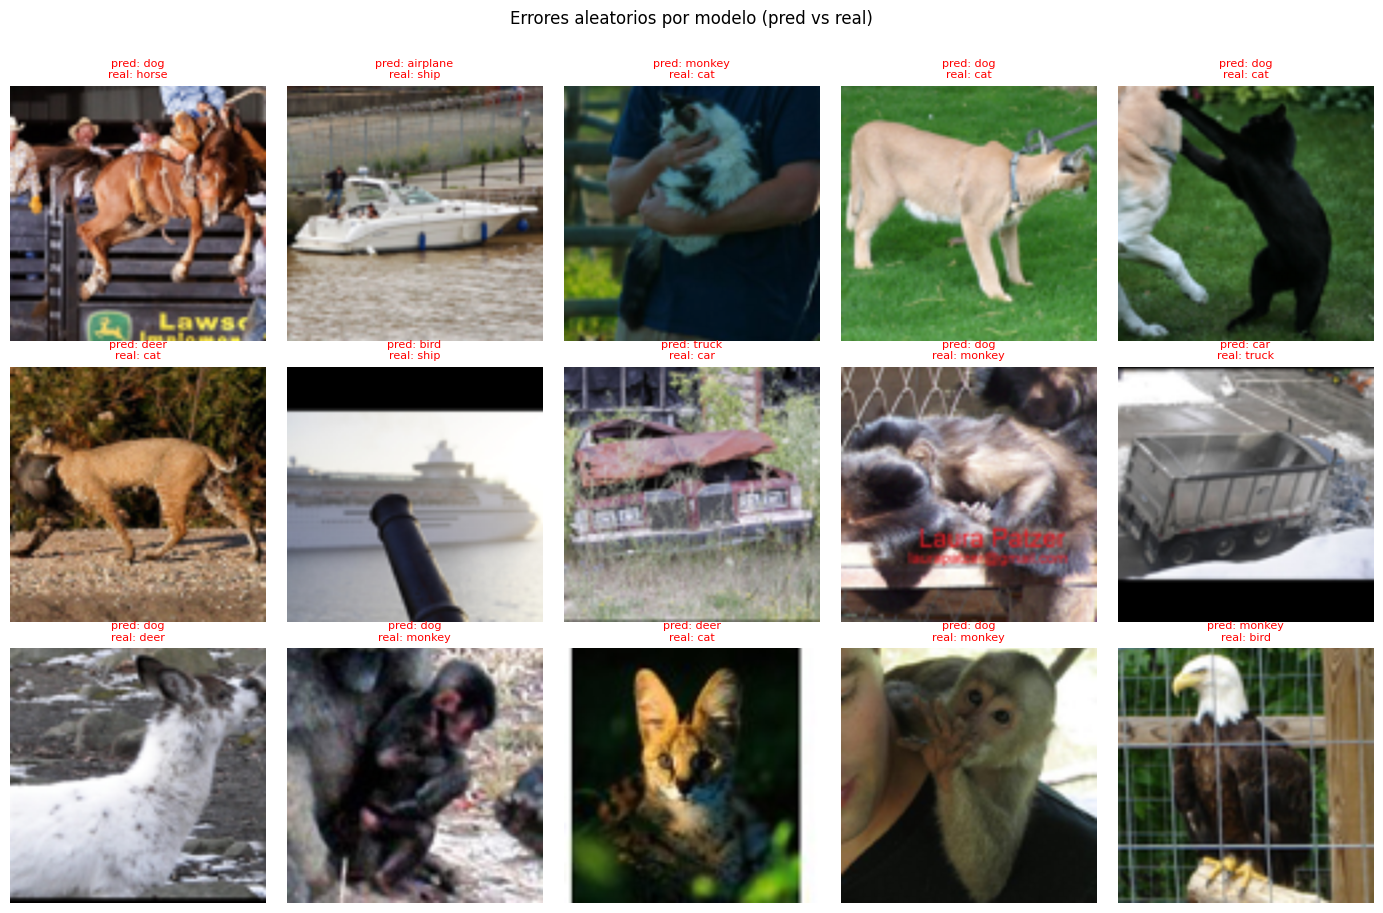

In [17]:
# Mostrar 5 errores aleatorios por modelo
import random

mean_t = torch.tensor(MEAN).view(3,1,1)
std_t  = torch.tensor(STD).view(3,1,1)

fig, axes = plt.subplots(len(resultados), 5, figsize=(14, 3 * len(resultados)))

for i, r in enumerate(resultados):
    r["modelo"].eval()
    errores = []  # (imagen_tensor, pred, real)
    with torch.no_grad():
        for imgs_b, y_b in val_loader:
            preds = r["modelo"](imgs_b.to(device)).argmax(1).cpu()
            for j in range(len(y_b)):
                if preds[j] != y_b[j]:
                    errores.append((imgs_b[j], preds[j].item(), y_b[j].item()))
            if len(errores) >= 50:
                break

    muestra = random.sample(errores, min(5, len(errores)))
    for j, (img_t, pred, real) in enumerate(muestra):
        img_vis = (img_t * std_t + mean_t).clamp(0, 1).permute(1, 2, 0)
        axes[i, j].imshow(img_vis)
        axes[i, j].set_title(f"pred: {CLASES[pred]}\nreal: {CLASES[real]}", fontsize=8, color="red")
        axes[i, j].axis("off")
    axes[i, 0].set_ylabel(r["nombre"], fontsize=9, rotation=0, labelpad=60, va="center")

plt.suptitle("Errores aleatorios por modelo (pred vs real)", y=1.01)
plt.tight_layout(); plt.show()

---
# Ejercicios

Cada ejercicio tiene una celda con el código comentado como guía.
Descomentá, completá los huecos y ejecutá.

## Ejercicio 1 — Probar otro modelo del zoo

Agregá **ConvNeXt-Tiny** al comparativo:

1. Cargá el modelo con `models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)`
2. Congelá todos los parámetros
3. Reemplazá la última capa: en ConvNeXt es `m.classifier[2]` (un `nn.Linear`)
4. Entrenalo 5 épocas con `entrenar()`
5. Añadí sus resultados a `resultados` y volvé a imprimir la tabla

> **Tip:** `m.classifier[2].in_features` te da el tamaño de entrada de esa capa.

In [ ]:
# Ejercicio 1 — completar aquí

# 1. Cargar el modelo con pesos pre-entrenados


# 2. Congelar backbone


# 3. Reemplazar la última capa (tip: m.classifier[2])


# 4. Entrenar 5 épocas


# 5. Agregar a resultados y mostrar tabla


## Ejercicio 2 — ¿Más épocas mejoran el modelo?

Volvé a entrenar **EfficientNet-B0** pero ahora con **10 épocas** en vez de 5.

1. Creá un modelo fresco con `preparar_modelo`
2. Entrenalo 10 épocas
3. Graficá `train_acc` y `val_acc` en el mismo plot
4. Respondé: ¿sigue mejorando? ¿En qué época deja de mejorar? ¿Hay overfitting?

In [ ]:
# Ejercicio 2 — completar aquí

# 1. Crear modelo fresco con preparar_modelo


# 2. Entrenar 10 épocas


# 3. Graficar train_acc y val_acc (y opcionalmente loss)


## Ejercicio 3 — Matriz de confusión

La matriz de confusión muestra **dónde se equivoca** el modelo: qué clase predice cuando la real es otra.

1. Tomá el mejor modelo de la tabla (el de mayor `val_acc`)
2. Recorrí `val_loader` completo y guardá todas las predicciones y etiquetas reales
3. Calculá la matriz con `sklearn.metrics.confusion_matrix`
4. Visualizala con `imshow`
5. Respondé: ¿qué par de clases confunde más el modelo? ¿Por qué creés que pasa?

In [ ]:
# Ejercicio 3 — completar aquí
from sklearn.metrics import confusion_matrix

# 1. Elegir el mejor modelo de la lista resultados


# 2. Recorrer val_loader y guardar predicciones y etiquetas reales


# 3. Calcular la matriz con confusion_matrix()


# 4. Visualizar con imshow (cmap="Blues")


## Ejercicio 4 — ¿Congelar o no congelar?

Hasta ahora congelamos **todo** el backbone y solo entrenamos la cabeza.
Pero también se puede descongelar las **últimas capas** del backbone para que se ajusten un poco al nuevo dataset.

1. Creá un EfficientNet-B0 con `preparar_modelo`
2. **Descongelá** las últimas capas del backbone (ver código abajo)
3. Entrenalo 5 épocas
4. Compará el `val_acc` con el EfficientNet-B0 que solo entrenó la cabeza

> **Pregunta:** ¿Mejora el accuracy? ¿Tarda más en entrenar? ¿Cuándo conviene hacer esto?

In [ ]:
# Ejercicio 4 — completar aquí

# 1. Crear modelo fresco con preparar_modelo


# 2. Descongelar las últimas capas del backbone
# Tip: el backbone de EfficientNet está en m.features
# Tip: features[-2:] selecciona los últimos 2 bloques


# 3. Entrenar 5 épocas


# 4. Comparar val_acc con el EfficientNet que solo entrenó la cabeza


---
# Conclusiones

El patrón de **transfer learning** es el mismo para cualquier arquitectura:
cargar pesos → congelar backbone → nueva cabeza → entrenar.
La diferencia entre modelos es el **trade-off** accuracy / tamaño / velocidad.

| Prioridad | Modelo sugerido |
|---|---|
| Máximo accuracy | ResNet-50 / EfficientNet-B3 |
| Balance accuracy–tamaño | EfficientNet-B0 |
| Edge / dispositivos limitados | MobileNet-V3 Small |
| Diseño moderno | ConvNeXt-Tiny |

**Conceptos clave de esta práctica:**
- Todos los modelos usan pesos de **ImageNet-1K** aplicados a imágenes de STL-10 que **nunca vieron**
- **Data augmentation** amplía la variedad de datos sin recolectar más imágenes
- Las **feature maps** muestran que el backbone aprende representaciones jerárquicas (bordes → texturas → conceptos)
- **Congelar vs descongelar** capas es un dial que controla cuánto se adapta el modelo al nuevo dominio
- El **análisis por clase** y la **visualización de errores** revelan patrones que el accuracy global no muestra
- La **loss** complementa al accuracy: muestra cuán seguro está el modelo en sus predicciones

La próxima clase vemos **Vision Transformers (ViT)**, donde el backbone ya no es convolucional
sino que usa atención global — y que vamos a usar para vectorizar rostros en el TP final de face recognition.